/var/folders/y4/__h0s0zj0qb4gjkjzynnyrcr0000gn/T/ipykernel_3337/3967969215.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(data_file, delim_whitespace=True, header=None,
/var/folders/y4/__h0s0zj0qb4gjkjzynnyrcr0000gn/T/ipykernel_3337/3967969215.py:86: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_all = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/catalogs/CENCcat_Mw_final.txt", delim_whitespace=True, header=None, names=columns)


所有断层图已绘制完成。


/var/folders/y4/__h0s0zj0qb4gjkjzynnyrcr0000gn/T/ipykernel_3337/3967969215.py:120: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_before_2000 = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/catalogs/catlog_before_2000.txt", delim_whitespace=True, header=None, names=columns)
/var/folders/y4/__h0s0zj0qb4gjkjzynnyrcr0000gn/T/ipykernel_3337/3967969215.py:121: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_from_2000 = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/catalogs/catlog_from_2000.txt", delim_whitespace=True, header=None, names=columns)
/var/folders/y4/__h0s0zj0qb4gjkjzynnyrcr0000gn/T/ipykernel_3337/3967969215.py:233: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  bigEQ = pd.read_csv("

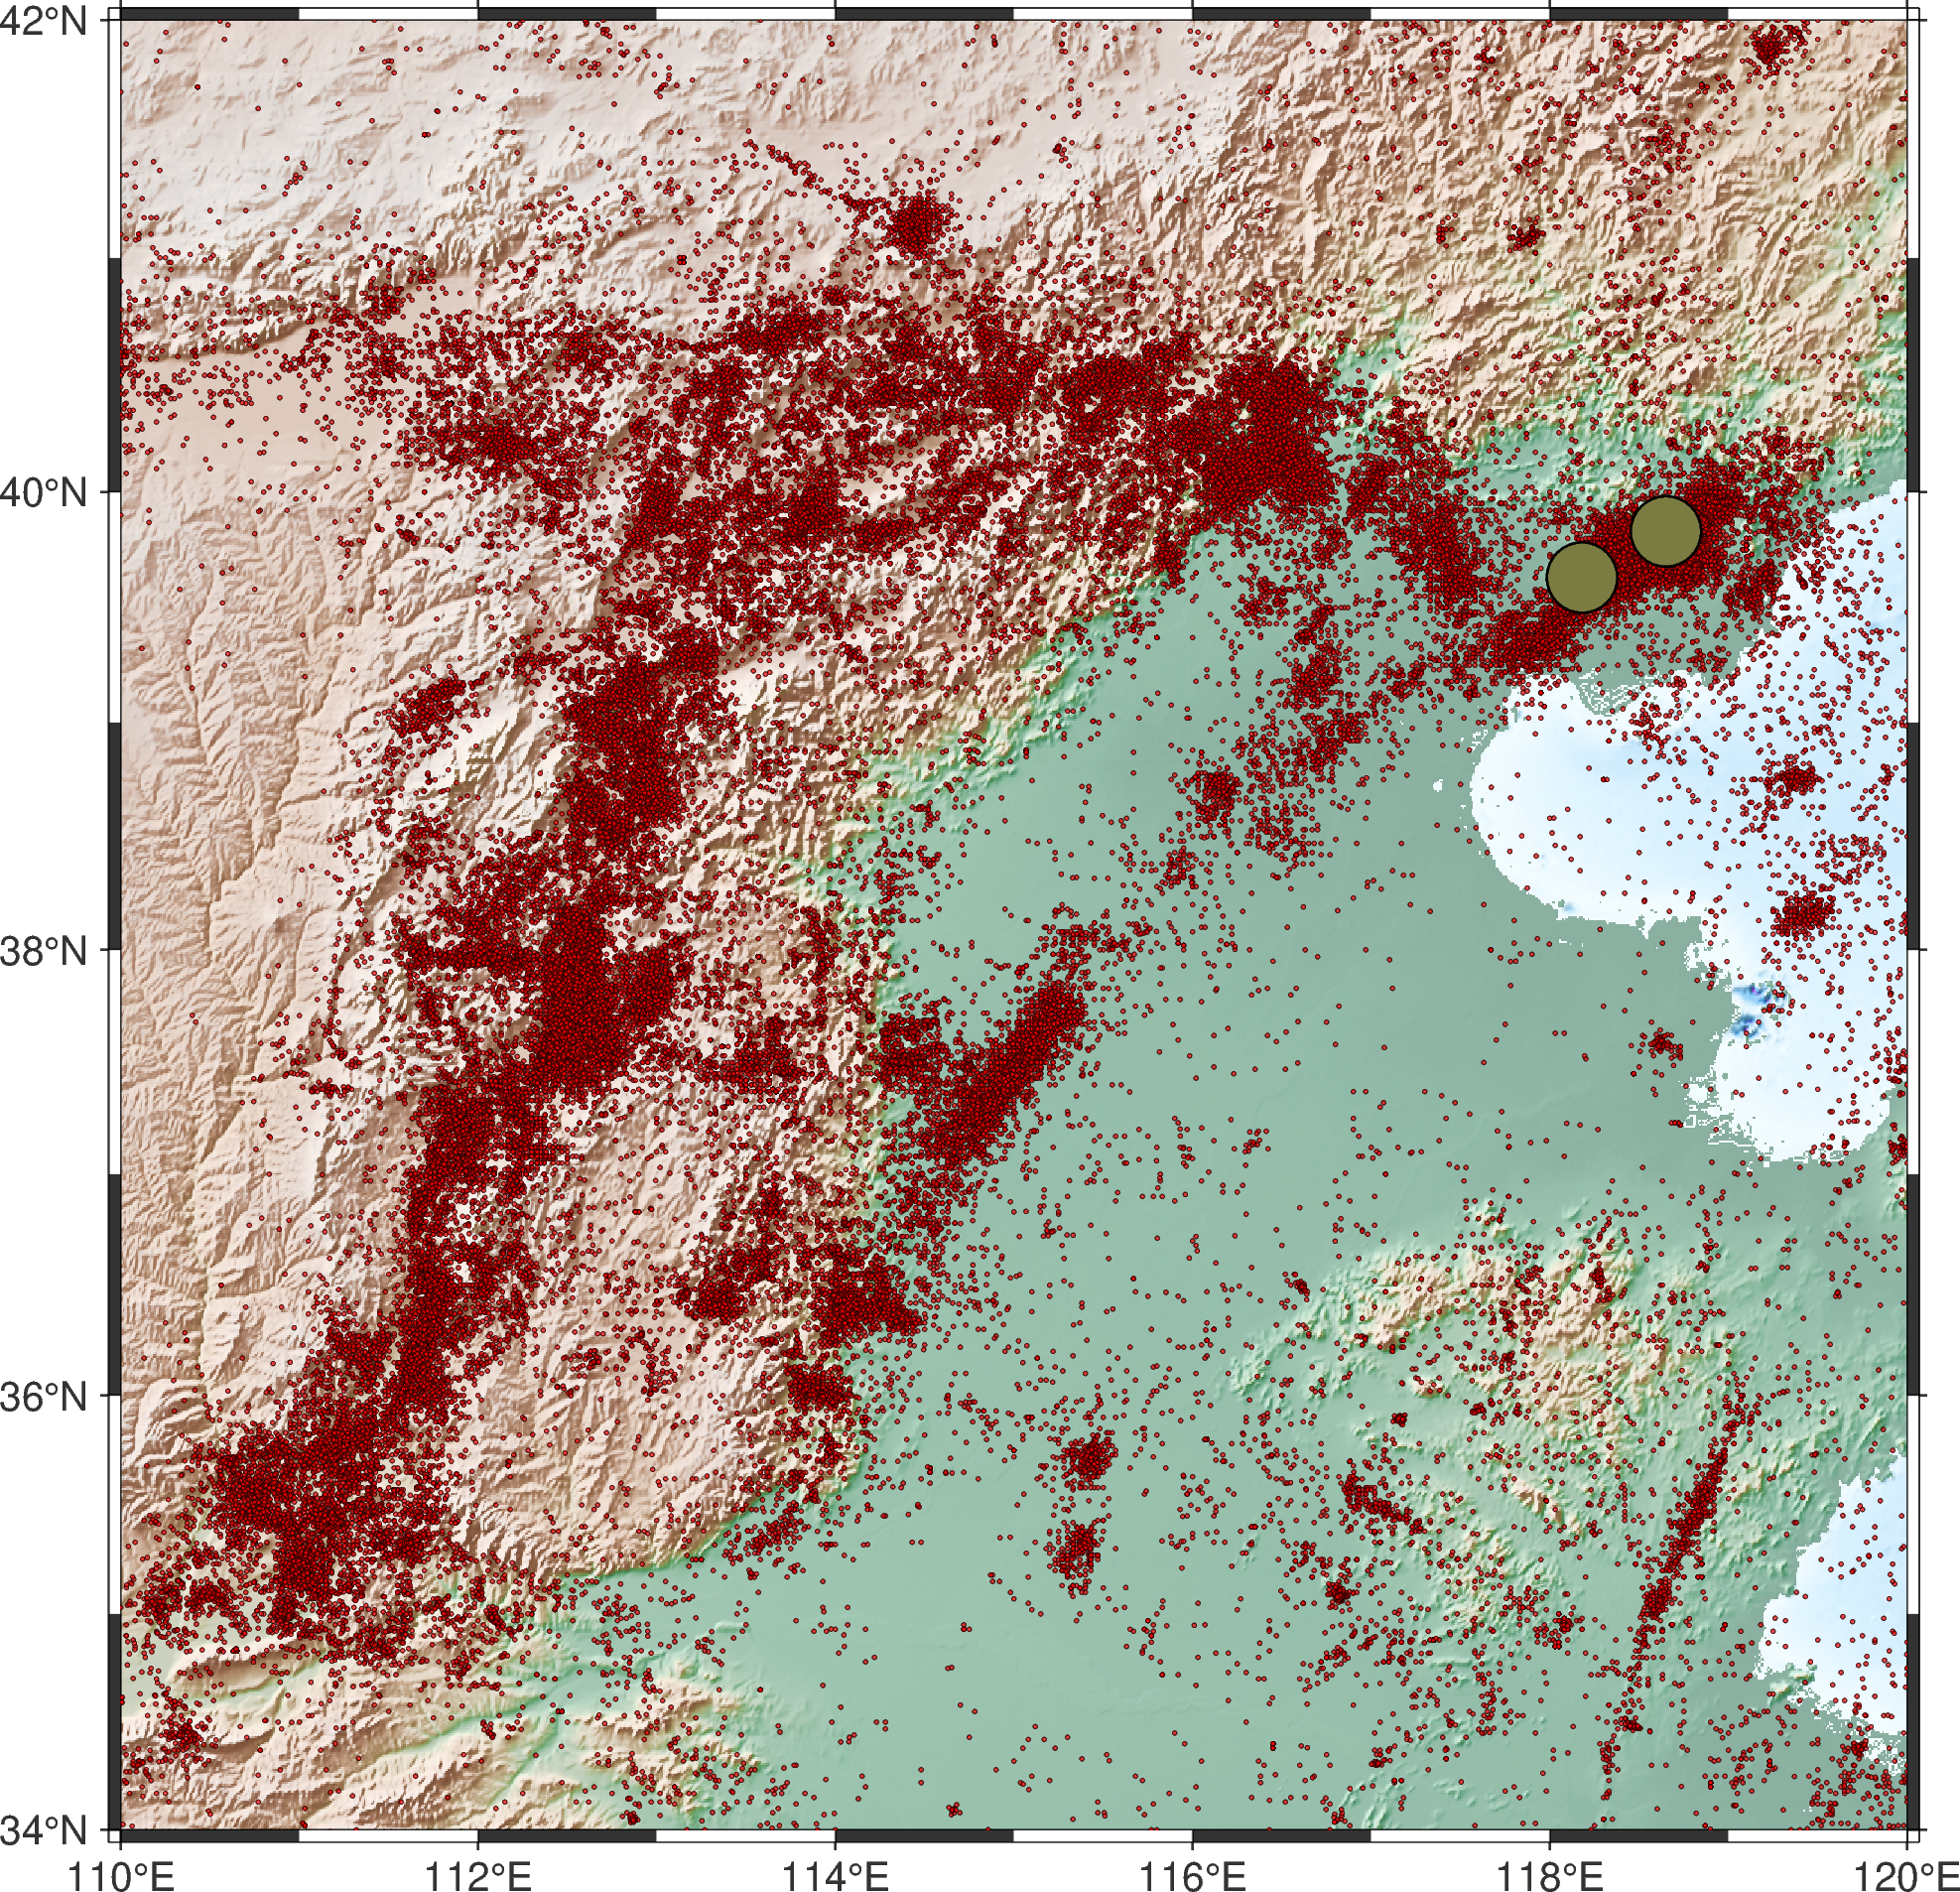

In [7]:
import subprocess
import pygmt
import pandas as pd
import os

# 设置地图区域和投影
region = [110, 120, 34, 42]  # 经度范围: 99 到 106，纬度范围: 22 到 33
grid = pygmt.datasets.load_earth_relief(resolution='30s', region=region)
# 创建一个地图对象
fig = pygmt.Figure()

fig.grdimage(grid=grid, region=region, projection='M6i',cmap='terra',frame=True, shading=True, transparency=20)  
#fig.text(position="MC", text="PyGMT", font="80p,Helvetica-Bold,red@75")
# 添加颜色条（colorbar）
# fig.colorbar(
#     cmap="light_gray.cpt",     # 使用与图像相同的 CPT 文件
#     position="JMR+o0.5c/0c+w10c/0.5c",  # 设置颜色条位置和大小
#     frame=["xaf+lElevation (m)"],  # 添加标签，单位为米
# )


# 读取转换后的经纬度数据
data_file = "/Users/chouyuhin/_Harvard/b-value/b_value/plotting/faults/202409-3D_CFM_lonlat.txt"  # 你的数据文件路径
data = pd.read_csv(data_file, delim_whitespace=True, header=None, 
                   names=[ "FaultName", "Longitude", "Latitude"])
# 筛选出在该区域内的断层数据
data = data[
    (data["Longitude"] >= region[0]) & (data["Longitude"] <= region[1]) & 
    (data["Latitude"] >= region[2]) & (data["Latitude"] <= region[3])
]
fault_names = data['FaultName'].unique()

# 遍历每个 Faultname 分组并绘图

for fault in fault_names:
    # 筛选出当前 Faultname 的数据
    
    fault_data = data[data['FaultName'] == fault]
  
    fig.plot(x=fault_data["Longitude"], y=fault_data["Latitude"], pen="1p,white", label="Active fault")
    # 添加标题（显示 Faultname）
    # fig.text(
    #     x=midpoint_x,  # 调整位置到图形左上角
    #     y=midpoint_y,
    #     text=f"Fault: {fault}",
    #     font="12p,Helvetica-Bold,black",
    #     offset="0.2c"
    # )
# 结束循环
print("所有断层图已绘制完成。")
# 添加活断层，假设有一个断层线文件“faults.gmt”
# # 读取转换后的经纬度数据
# shaoqiao_file = "G:/BHT/交际河断裂坐标.txt"  # 你的数据文件路径
# shaoqiao = pd.read_csv(shaoqiao_file, delim_whitespace=True, header=None, 
#                    names=["Longitude", "Latitude"])
# fig.plot(x=shaoqiao["Longitude"], y=shaoqiao["Latitude"], pen="1.5p,black", label="Active fault")

# puduhe_file = "G:/BHT/普渡河断裂坐标.txt"  # 你的数据文件路径
# puduhe = pd.read_csv(puduhe_file, delim_whitespace=True, header=None, 
#                    names=["Longitude", "Latitude"])
# fig.plot(x=puduhe["Longitude"], y=puduhe["Latitude"], pen="1.5p,black", label="Active fault")

# xiaojiangdong_file = "G:/BHT/小江断裂东支坐标.txt"  # 你的数据文件路径
# xiaojiangdong = pd.read_csv(xiaojiangdong_file, delim_whitespace=True, header=None, 
#                    names=["Longitude", "Latitude"])
# fig.plot(x=xiaojiangdong["Longitude"], y=xiaojiangdong["Latitude"], pen="1.5p,black", label="Active fault")

# xiaojiangxi_file = "G:/BHT/小江断裂西支坐标.txt"  # 你的数据文件路径
# xiaojiangxi = pd.read_csv(xiaojiangxi_file, delim_whitespace=True, header=None, 
#                    names=["Longitude", "Latitude"])
# fig.plot(x=xiaojiangxi["Longitude"], y=xiaojiangxi["Latitude"], pen="1.5p,black", label="Active fault")

# zemuhe_file = "G:/BHT/则木河断裂坐标.txt"  # 你的数据文件路径
# zemuhe = pd.read_csv(zemuhe_file, delim_whitespace=True, header=None, 
#                    names=["Longitude", "Latitude"])
# fig.plot(x=zemuhe["Longitude"], y=zemuhe["Latitude"], pen="1.5p,black", label="Active fault")

# zhaoqiao_file = "G:/BHT/昭巧断裂坐标.txt"  # 你的数据文件路径
# zhaoqiao = pd.read_csv(zhaoqiao_file, delim_whitespace=True, header=None, 
#                    names=["Longitude", "Latitude"])
# fig.plot(x=zhaoqiao["Longitude"], y=zhaoqiao["Latitude"], pen="1.5p,black", label="Active fault")
# print("所有活断层已绘制完成。")

# 读取所有地震目录
columns = ["year", "month", "day", "hour", "minute", "second", "latitude", "longitude", "depth", "magnitude_type", "magnitude"]
data_all = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/catalogs/CENCcat_Mw_final.txt", delim_whitespace=True, header=None, names=columns)
# 筛选出在该区域内的断层数据

# 震级小于5
data_small = data_all[data_all["magnitude"] <7]

fig.plot(
    x=data_all["longitude"],
    y=data_all["latitude"],
    style="c0.04c", 
    #size=0.05 * (1.5**data_before_2000['magnitude']),  # 根据震级设置半径
    fill="red",
    transparency=30,
    pen="0p"  # 黑色边界
)

# 读取城市坐标文件（绘制白色填充黑色边框的圆点）
# cities = pd.read_csv("G:/BHT/keycities.txt", sep=" ", header=None, names=["city","longitude", "latitude"], 
#                     usecols=[0,1, 2], dtype={"longitude": float, "latitude": float})

# fig.plot(x=cities["longitude"], y=cities["latitude"], style="c0.2c", fill="yellow", pen="0.5p,white",transparency=20)
# 读取城市坐标（绘制白色填充黑色边框的圆点）

# 6. 添加城市标签
# for i, row in cities.iterrows():
#     fig.text(x=row["longitude"], y=row["latitude"], text=row["city"], font="12p,black", justify="LT")


# 读取5级以上地震目录
# 读取文件数据，并命名列
columns = ["year", "month", "day", "hour", "minute", "second", "latitude", "longitude", "depth", "magnitude_type", "magnitude"]

# 读取文件

data_before_2000 = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/catalogs/catlog_before_2000.txt", delim_whitespace=True, header=None, names=columns)
data_from_2000 = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/catalogs/catlog_from_2000.txt", delim_whitespace=True, header=None, names=columns)
# # 按震级大小画圆，以免被覆盖
data_before_2000 = data_before_2000.sort_values(by="magnitude", ascending=True)
data_from_2000 = data_from_2000.sort_values(by="magnitude", ascending=True)




# # 震级5.0-5.9
# data_before_2000_56 = data_before_2000[(data_before_2000["magnitude"] >= 5) & (data_before_2000["magnitude"] < 6)]
# data_from_2000_56 = data_from_2000[(data_from_2000["magnitude"] >= 5) & (data_from_2000["magnitude"] < 6)]

# # 绘制 5-5.9 数据 
# #fig.plot(
# #    x=data_before_2000_56["longitude"],
# #    y=data_before_2000_56["latitude"],
# #    style="c0.35c",  # 基本圆圈样式，后续会缩放
# #    #size=0.05 * (1.5**data_before_2000['magnitude']),  # 根据震级设置半径
# #    fill="#7b7c41",
# #   
# #    pen="0.5p,black"  # 黑色边界
# #)
# #fig.plot(
# #    x=data_from_2000_56["longitude"],
# #    y=data_from_2000_56["latitude"],
# #    style="c0.35c",  # 基本圆圈样式，后续会缩放
# #    #size=0.05 * (1.5**data_from_2000['magnitude']),  # 根据震级设置半径
# #    fill="#dbde57",
# #   
# #    pen="0.5p,black"  # 黑色边界
# #)

# # 6.0-6.9
# data_before_2000_67 = data_before_2000[(data_before_2000["magnitude"] >= 6) & (data_before_2000["magnitude"] < 7)]
# data_from_2000_67 = data_from_2000[(data_from_2000["magnitude"] >= 6) & (data_from_2000["magnitude"] < 7)]
# # 绘制 6-6.9 数据 
# fig.plot(
#     x=data_before_2000_67["longitude"],
#     y=data_before_2000_67["latitude"],
#     style="c0.4c",  # 基本圆圈样式，后续会缩放
#     #size=0.05 * (1.5**data_before_2000['magnitude']),  # 根据震级设置半径
#     fill="#7b7c41",
   
#     pen="0.5p,black"  # 黑色边界
# )


# fig.plot(
#     x=data_from_2000_67["longitude"],
#     y=data_from_2000_67["latitude"],
#     style="c0.4c",  # 基本圆圈样式，后续会缩放
#     #size=0.05 * (1.5**data_from_2000['magnitude']),  # 根据震级设置半径
#     fill="#dbde57",
   
#     pen="0.5p,black"  # 黑色边界
# )

#7-7.9
data_before_2000_78 = data_before_2000[(data_before_2000["magnitude"] >= 7) & (data_before_2000["magnitude"] < 8)]
data_from_2000_78 = data_from_2000[(data_from_2000["magnitude"] >= 7) & (data_from_2000["magnitude"] < 8)]
# 绘制 6-6.9 数据 
fig.plot(
    x=data_before_2000_78["longitude"],
    y=data_before_2000_78["latitude"],
    style="c0.6c",  # 基本圆圈样式，后续会缩放
    #size=0.05 * (1.5**data_before_2000['magnitude']),  # 根据震级设置半径
    fill="#7b7c41",
   
    pen="0.5p,black"  # 黑色边界
)
fig.plot(
    x=data_from_2000_78["longitude"],
    y=data_from_2000_78["latitude"],
    style="c0.6c",  # 基本圆圈样式，后续会缩放
    #size=0.05 * (1.5**data_from_2000['magnitude']),  # 根据震级设置半径
    fill="#dbde57",
   
    pen="0.5p,black"  # 黑色边界
)
# for i, row in data_before_2000_78.iterrows():
#     fig.text(x=row["longitude"], y=row["latitude"], text=f"{row["year"]}+{row["month"]}+{row["day"]}+{row["magnitude_type"]}+{row["magnitude"]}", font="12p,black", justify="LT")
# for i, row in data_from_2000_78.iterrows():
#     fig.text(x=row["longitude"], y=row["latitude"], text=f"{row["year"]}+{row["month"]}+{row["day"]}+{row["magnitude_type"]}+{row["magnitude"]}", font="12p,black", justify="LT")
# #8-8.9
data_before_2000_89 = data_before_2000[data_before_2000["magnitude"] >= 8]
data_from_2000_89 = data_from_2000[data_from_2000["magnitude"] >= 8]
# print(data_before_2000_89)
# print(data_from_2000_89)
# fig.plot(
#     x=data_before_2000_89["longitude"],
#     y=data_before_2000_89["latitude"],
#     style="c1.1c",  # 基本圆圈样式，后续会缩放
#     #size=0.05 * (1.5**data_before_2000['magnitude']),  # 根据震级设置半径
#     fill="#7b7c41",
   
#     pen="0.5p,black"  # 黑色边界
# )
fig.plot(
    x=data_from_2000_89["longitude"],
    y=data_from_2000_89["latitude"],
    style="c0.8c",  # 基本圆圈样式，后续会缩放
    #size=0.05 * (1.5**data_from_2000['magnitude']),  # 根据震级设置半径
    fill="#dbde57",
   
    pen="0.5p,black"  # 黑色边界
)
# for i, row in data_before_2000_89.iterrows():
#     fig.text(x=row["longitude"], y=row["latitude"], text=f"{row["year"]}+{row["month"]}+{row["day"]}+{row["magnitude_type"]}+{row["magnitude"]}", font="12p,black", justify="LT")
# for i, row in data_from_2000_89.iterrows():
#     fig.text(x=row["longitude"], y=row["latitude"], text=f"{row["year"]}+{row["month"]}+{row["day"]}+{row["magnitude_type"]}+{row["magnitude"]}", font="12p,black", justify="LT")
# # # 添加大震位置
columns = ['year', 'month', 'day', 'hour', 'minute', 'second', 'latitude', 'longitude', 'anything', 'mag_type', 'magnitude', 'datetime']
bigEQ = pd.read_csv("/Users/chouyuhin/_Harvard/b-value/b_value/bigEQs.csv", delim_whitespace=',', header=None, names=columns)
# 绘制地震事件为五角星符号
fig.plot(
    x=bigEQ["longitude"],
    y=bigEQ["latitude"],
    style="a0.6c",  # 五角星符号，大小为0.4厘米，可根据需求调整
    fill="red",
    pen="0p,white"  # 黑色边框
)
# # 6. 添加大震标签
# # for i, row in bigEQ.iterrows():
# #     fig.text(x=row["longitude"], y=row["latitude"], text=row["location"], font="12p,black", justify="LT")
# 设置边框为黑色实线
# fig.basemap(frame=True, pen='1p,black')
fig.show()
# # 保存为 EPS 格式，设置分辨率
# # 2. 输出高兼容性PDF（保留矢量元素）
fig.savefig("Fig4A_huabei.pdf")  # 最高抗锯齿)